# Latent Dirichlet Allocation Topic Modelling 

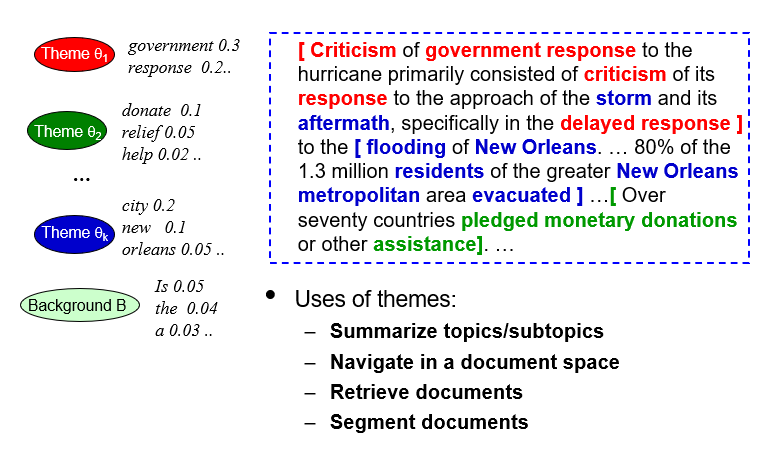

In [1]:

import pandas as pd
import random
import warnings

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


In [ ]:

warnings.filterwarnings('ignore')


In [2]:

npr = pd.read_csv('npr.csv')
npr.shape


(11992, 1)

In [3]:

print("Sample Article:\n", npr['Article'].iloc[0], "\n")


Sample Article:
 In the Washington of 2016, even when the policy can be bipartisan, the politics cannot. And in that sense, this year shows little sign of ending on Dec. 31. When President Obama moved to sanction Russia over its alleged interference in the U. S. election just concluded, some Republicans who had long called for similar or more severe measures could scarcely bring themselves to approve. House Speaker Paul Ryan called the Obama measures ”appropriate” but also ”overdue” and ”a prime example of this administration’s ineffective foreign policy that has left America weaker in the eyes of the world.” Other GOP leaders sounded much the same theme. ”[We have] been urging President Obama for years to take strong action to deter Russia’s worldwide aggression, including its   operations,” wrote Rep. Devin Nunes,  . chairman of the House Intelligence Committee. ”Now with just a few weeks left in office, the president has suddenly decided that some stronger measures are indeed warran

In [3]:

cv = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = cv.fit_transform(npr['Article'])

print(f"Document-Term Matrix shape: {dtm.shape}")
print(f"Total unique words: {len(cv.get_feature_names_out())}\n")


Document-Term Matrix shape: (11992, 54777)
Total unique words: 54777



In [5]:
# Randomly display some words
print("Random sample words:")
print(random.sample(list(cv.get_feature_names_out()), 25))
print("\n")


Random sample words:
['hitchhiked', 'informational', 'mcnabb', 'eyeballs', 'unpleasantness', 'malay', 'badu', 'signs', 'incomes', 'write', 'hoisting', 'mcclintock', 'pope', 'venezuelans', 'sunja', 'securing', 'callouts', 'rc', 'solicitation', 'switched', 'dieleman', 'don', 'pacheco', 'airdropping', 'brothel']




In [6]:
#  LDA Model Training

lda = LatentDirichletAllocation(n_components=7, random_state=42)
lda.fit(dtm)

print("LDA training completed!\n")


LDA training completed!



In [7]:
#  Show Top Words for Each Topic

words = cv.get_feature_names_out()

def display_topics(model, feature_names, n_top_words=15):
    
    for idx, topic in enumerate(model.components_):
        
        top_features = [feature_names[i] for i in topic.argsort()[-n_top_words:]]
        
        print(f"TOPIC #{idx}: {', '.join(top_features)}\n")

display_topics(lda, words)


TOPIC #0: companies, money, year, federal, 000, new, percent, government, company, million, care, people, health, said, says

TOPIC #1: military, house, security, russia, government, npr, reports, says, news, people, told, police, president, trump, said

TOPIC #2: way, world, family, home, day, time, water, city, new, years, food, just, people, like, says

TOPIC #3: time, new, don, years, medical, disease, patients, just, children, study, like, women, health, people, says

TOPIC #4: voters, vote, election, party, new, obama, court, republican, campaign, people, state, president, clinton, said, trump

TOPIC #5: years, going, ve, life, don, new, way, music, really, time, know, think, people, just, like

TOPIC #6: student, years, data, science, university, people, time, schools, just, education, new, like, students, school, says



In [8]:
#  Assign Topic Labels to Articles

topic_results = lda.transform(dtm)
npr['Topic'] = topic_results.argmax(axis=1)
npr['Topic']


0        1
1        1
2        1
3        1
4        2
        ..
11987    1
11988    4
11989    3
11990    4
11991    0
Name: Topic, Length: 11992, dtype: int64

In [9]:
npr

,Article,Topic
0,"In the Washington of 2016, even when the polic...",1
1,Donald Trump has used Twitter — his prefe...,1
2,Donald Trump is unabashedly praising Russian...,1
3,"Updated at 2:50 p. m. ET, Russian President Vl...",1
4,"From photography, illustration and video, to d...",2
...,...,...
11987,The number of law enforcement officers shot an...,1
11988,"Trump is busy these days with victory tours,...",4
11989,It’s always interesting for the Goats and Soda...,3
11990,The election of Donald Trump was a surprise to...,4


In [10]:

# human-readable labels

topic_labels = {0:'C1', 1:'C2', 2:'C3', 3:'C4', 4:'C5', 5:'C6', 6:'C7'}

npr['Topic Label'] = npr['Topic'].map(topic_labels)

npr['Topic Label']


0        C2
1        C2
2        C2
3        C2
4        C3
         ..
11987    C2
11988    C5
11989    C4
11990    C5
11991    C1
Name: Topic Label, Length: 11992, dtype: object

In [9]:
# Final Output

print("\n Topic Assigned to First 10 Articles:\n")

print(npr[['Article', 'Topic', 'Topic Label']].head(10))



 Topic Assigned to First 10 Articles:

                                             Article  Topic Topic Label
0  In the Washington of 2016, even when the polic...      1          C2
1    Donald Trump has used Twitter  —   his prefe...      1          C2
2    Donald Trump is unabashedly praising Russian...      1          C2
3  Updated at 2:50 p. m. ET, Russian President Vl...      1          C2
4  From photography, illustration and video, to d...      2          C3
5  I did not want to join yoga class. I hated tho...      3          C4
6  With a   who has publicly supported the debunk...      3          C4
7  I was standing by the airport exit, debating w...      2          C3
8  If movies were trying to be more realistic, pe...      3          C4
9  Eighteen years ago, on New Year’s Eve, David F...      2          C3


### Best K value

In [ ]:

for k in [5, 10, 15]:
    print("\n------ Topics =", k, "------")
    
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=42
    )
    lda.fit(dtm)
    
    for idx, topic in enumerate(lda.components_):
        top_words = [cv.get_feature_names_out()[i] 
                     for i in topic.argsort()[-10:]]
        print(f"Topic {idx+1}: {' '.join(top_words)}")



------ Topics = 5 ------
Topic 1: state year company percent new care said health people says
Topic 2: government reports news told people says police president trump said
Topic 3: think way years know new time people just says like
Topic 4: students study children health women just school like people says
Topic 5: obama new republican campaign state people president clinton said trump

------ Topics = 10 ------



Most text datasets naturally contain between 5–20 meaningful topics

For typical real-world datasets (news, questions, customer reviews, forum posts):

    High-quality corpora → 6–12 topics
    
    Medium-size datasets → 10–20 topics
    
    Very large corpora (millions of docs) → 30–100 topics

So 20 is chosen as a balance:

→ Not too low
→ Not too high
